# Comparing models trained with LFP loss vs not

Looking at the saved neural data from these models

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import pickle as pk
import sys
import importlib

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import population_utils as pu

## get list of trained models

In [2]:
# lfp models (lfp) — theta 4.0

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta4_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '4.0', '.mat'])
# remove directories 
lfp_theta4_model_list = [m.split('/')[-1] for m in lfp_theta4_model_list]
lfp_theta4_model_list.sort()

# print(lfp_theta4_model_list)
print(len(lfp_theta4_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta4_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

11
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_163824.mat, Test perf: 0.98, Train trials: 12101
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_163840.mat, Test perf: 0.96, Train trials: 14101
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_164107.mat, Test perf: 0.99, Train trials: 14501
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_164848.mat, Test perf: 0.96, Train trials: 9701
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_165124.mat, Test perf: 0.98, Train trials: 9601
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_170239.mat, Test perf: 0.98, Train trials: 12801
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_170405.mat, Test perf: 0.96, Train trials: 24501
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_170411.mat, Test perf: 0.99, Train trials: 12101
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_18_171555.mat, Test perf: 0.98, Train trials: 10201
Model: Task_xor_N_200_Jitte

In [3]:
# lfp models (lfp) — theta 8.0

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta8_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '8.0', '.mat'])

# remove directories 
lfp_theta8_model_list = [m.split('/')[-1] for m in lfp_theta8_model_list]
lfp_theta8_model_list.sort()

# print(lfp_theta8_model_list)
print(len(lfp_theta8_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta8_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

11
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_200752.mat, Test perf: 0.99, Train trials: 6701
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_201526.mat, Test perf: 0.96, Train trials: 13501
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_201635.mat, Test perf: 1.0, Train trials: 15701
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_202223.mat, Test perf: 0.97, Train trials: 13401
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_202608.mat, Test perf: 0.96, Train trials: 10101
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_203420.mat, Test perf: 0.96, Train trials: 9901
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_205135.mat, Test perf: 0.97, Train trials: 29301
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_205326.mat, Test perf: 1.0, Train trials: 21401
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_18_210218.mat, Test perf: 0.96, Train trials: 15001
Model: Task_xor_N_200_Jitter_

In [6]:
# remove models with less than 95% performance

import os

def remove_low_perf_models(model_list, model_dir, perf_thresh=0.95):
    good_models = []
    for i, model_name in enumerate(model_list):
        model_path = os.path.join(model_dir, model_name)
        model_data = scipy.io.loadmat(model_path)
        perf = model_data['eval_perf_mean'][0][0]
        if perf < perf_thresh:
            print(f'Removing model {model_name} with performance {perf}')
            os.remove(model_path)
    return 

remove_low_perf_models(lfp_theta4_model_list, lfp_model_dir, perf_thresh=0.95)
remove_low_perf_models(lfp_theta8_model_list, lfp_model_dir, perf_thresh=0.95)

Removing model Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_140343.mat with performance 0.0
Removing model Task_xor_N_200_Jitter_10_10_LFPdelay_8.0_2025_09_16_151444.mat with performance 0.0


## study models

### dict keys
neural_dict has 2 keys:
- 'r' is trials x neurons x time
- 'epsp' is trials x time

bhv_dict has 2 keys:
- 'perf' is trials (0/1)
- 'trial_type' is list of length trials
    - if changed to np.array, is trials x 2

In [ ]:
# delay150
settings = {
        'T': 400, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [4]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# base code for loading data for each model type

model_lists = [xlfp_model_list, lfp_theta4_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

    for model_name in model_list:
        print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))

        break
    break


### simple behavior plots

In [5]:
avg_perf_lfp4 = []
avg_perf_lfp8 = []

model_lists = [lfp_theta4_model_list, lfp_theta8_model_list] #, lfp_alpha_model_list]
model_dirs = [lfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['lfp_theta4', 'lfp_theta8'] #, 'lfp_alpha']
condn = 'delay400'

for model_list, model_dir, model_list_name in zip(model_lists, model_dirs, model_list_names):
    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        bhv_dict = pk.load(open(os.path.join(output_dir, f'bhv_dict_{condn}.pkl'), 'rb'))
        if model_list_name == 'lfp_theta4':
            avg_perf_lfp4.append(np.mean(bhv_dict['perf']))
        elif model_list_name == 'lfp_theta8':
            avg_perf_lfp8.append(np.mean(bhv_dict['perf']))

print(f'LFP 4Hz avg perf: {np.mean(avg_perf_lfp4)}, std: {np.std(avg_perf_lfp4)}')
print(f'LFP 8Hz avg perf: {np.mean(avg_perf_lfp8)}, std: {np.std(avg_perf_lfp8)}')

LFP 4Hz avg perf: 0.6245454545454545, std: 0.21814772460895876
LFP 8Hz avg perf: 0.7654545454545455, std: 0.22516109935145773


Mann-Whitney U test statistic: 46.00, p-value: 0.36


/tmp/ipykernel_846277/912580839.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([avg_perf_lfp4, avg_perf_lfp8], labels=['LFP 4Hz', 'LFP 8Hz'])


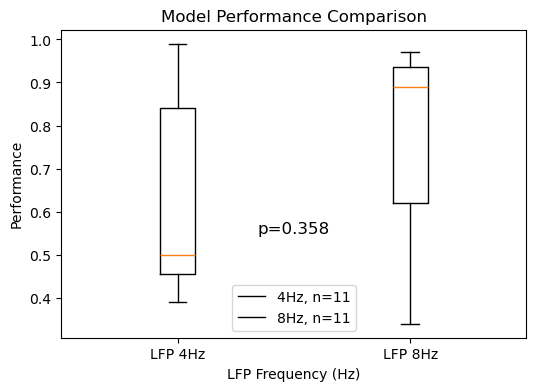

In [6]:
# box plots comparing model perfs from both groups, with stats -- from when there were 11 of each model type

plt.figure(figsize=(6,4))
plt.boxplot([avg_perf_lfp4, avg_perf_lfp8], labels=['LFP 4Hz', 'LFP 8Hz'])

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(avg_perf_lfp4, avg_perf_lfp8)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))
if p<0.05:
    plt.text(1.5, 0.1, '*', fontsize=20, ha='center')
plt.text(1.5, 0.55, f'p={p:.3f}', fontsize=12, ha='center')


plt.ylabel('Performance')
plt.xlabel('LFP Frequency (Hz)')
plt.title('Model Performance Comparison')
plt.legend([f'4Hz, n={len(avg_perf_lfp4)}', f'8Hz, n={len(avg_perf_lfp8)}'])
# plt.grid()
plt.show()

### Connectivity plots

In [7]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import connectivity_utils as cu

Processing model type: lfp_theta4, number of models: 11


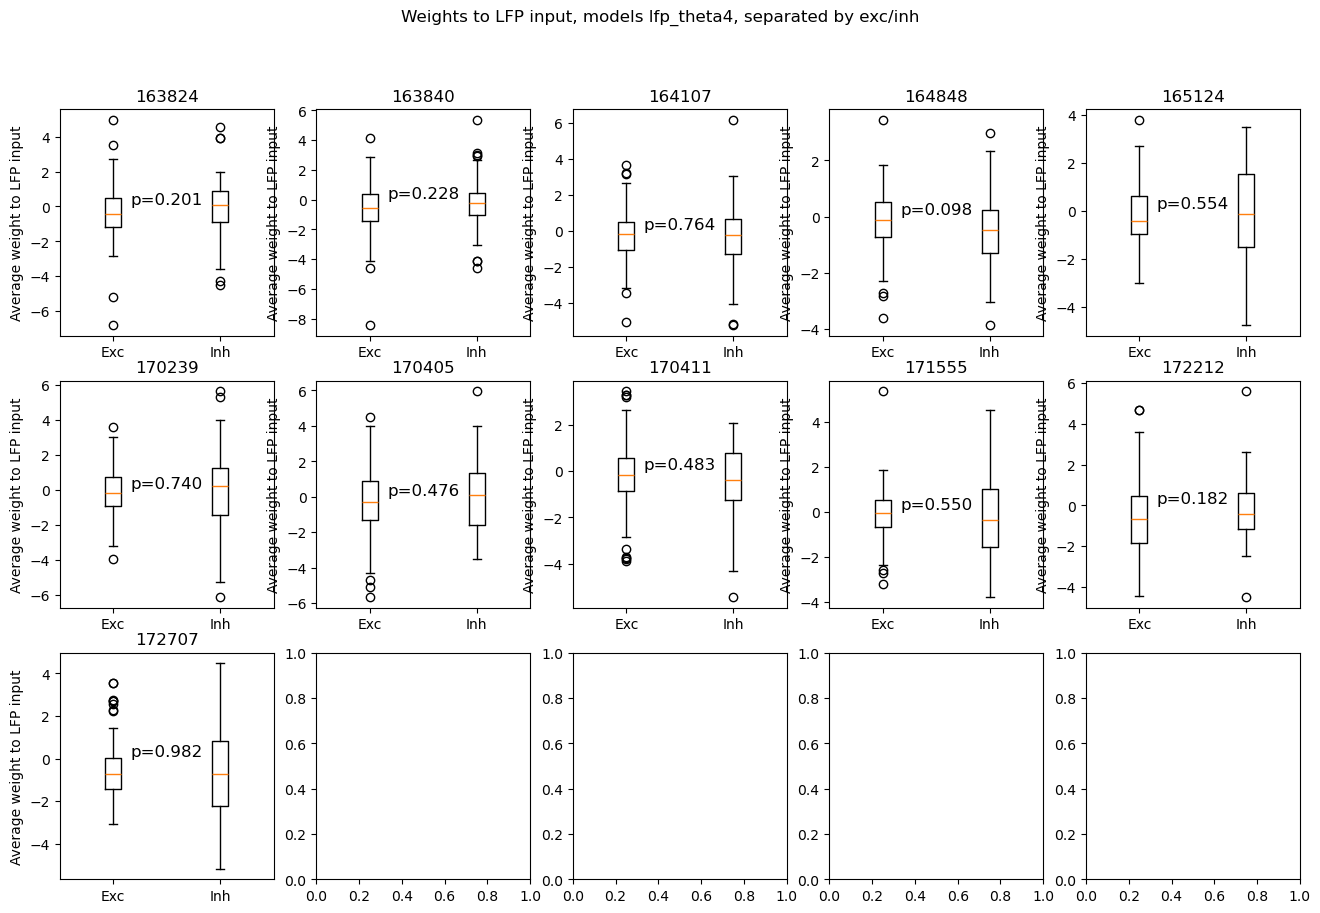

Processing model type: lfp_theta8, number of models: 11


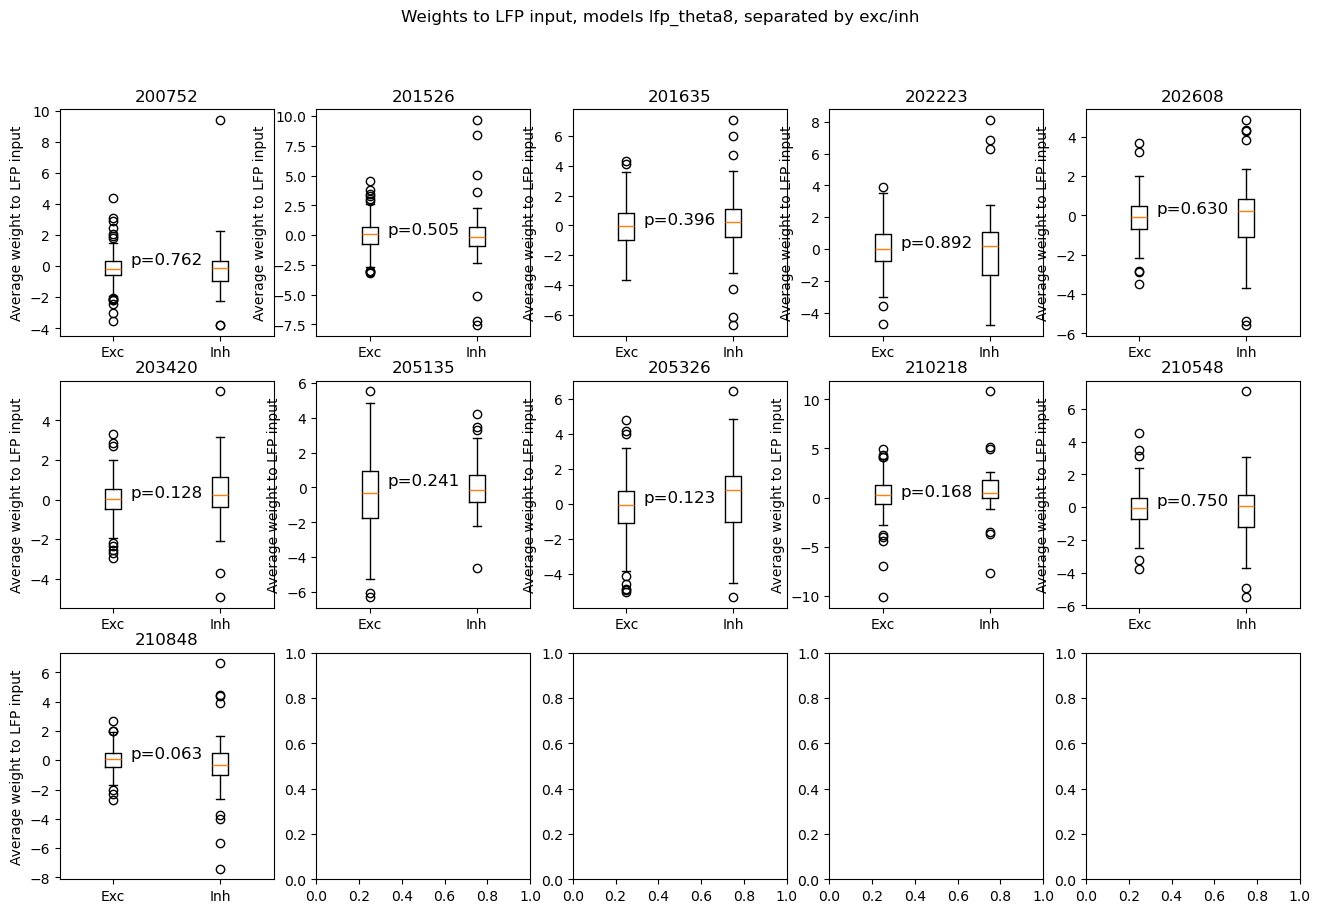

In [8]:
model_lists = [lfp_theta4_model_list, lfp_theta8_model_list] #, lfp_alpha_model_list]
model_dirs = [lfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['lfp_theta4', 'lfp_theta8'] #, 'lfp_alpha']

for (model_list, model_dir, model_list_name) in zip(model_lists, model_dirs, model_list_names):
    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    fig, axs = plt.subplots(3,5, figsize=(16,10))
    axs = axs.flatten()
    for i, model_name in enumerate(model_list):
        model_path = os.path.join(lfp_model_dir, model_name)
        model_data = scipy.io.loadmat(model_path)
        
        w_in_lfp = np.squeeze(model_data['w_in_lfp'])
        exc_ind = np.where(model_data['exc']==1)[0]
        inh_ind = np.where(model_data['exc']==0)[0]
        
        axs[i].boxplot([w_in_lfp[exc_ind], w_in_lfp[inh_ind]])
        axs[i].set_xticklabels(['Exc', 'Inh'])
        stat, p = mannwhitneyu(w_in_lfp[exc_ind], w_in_lfp[inh_ind])
        # print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))
        if p<0.05:
            axs[i].text(1.5, 0.1, '*', fontsize=20, ha='center')
        axs[i].text(1.5, 0.1, f'p={p:.3f}', fontsize=12, ha='center')
        axs[i].set_ylabel('Average weight to LFP input')
        axs[i].set_title(f'{model_name[-10:-4]}')
    plt.suptitle(f'Weights to LFP input, models {model_list_name}, separated by exc/inh')
    plt.show()

Processing model type: lfp_theta4, number of models: 11


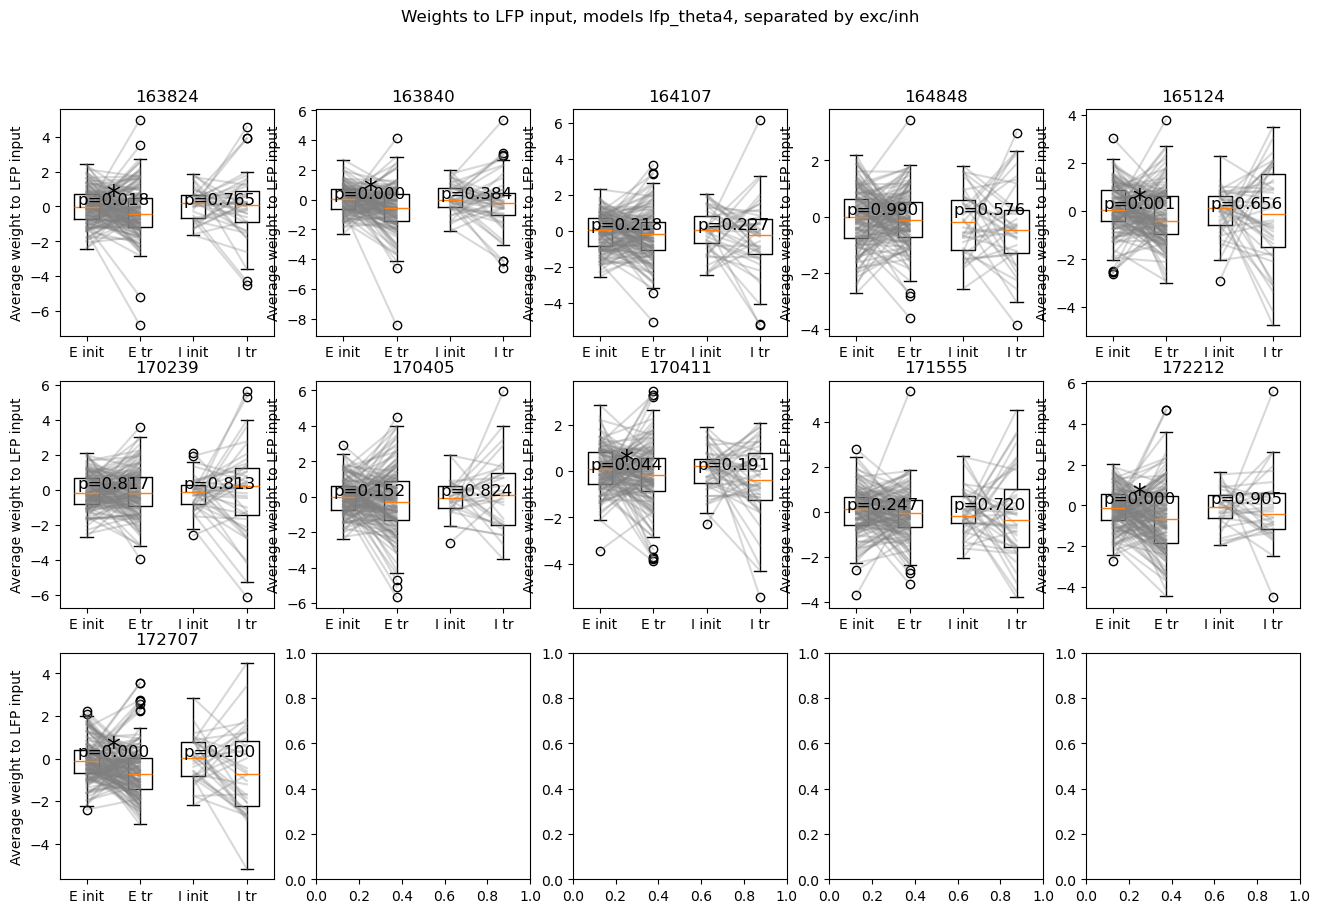

Processing model type: lfp_theta8, number of models: 11


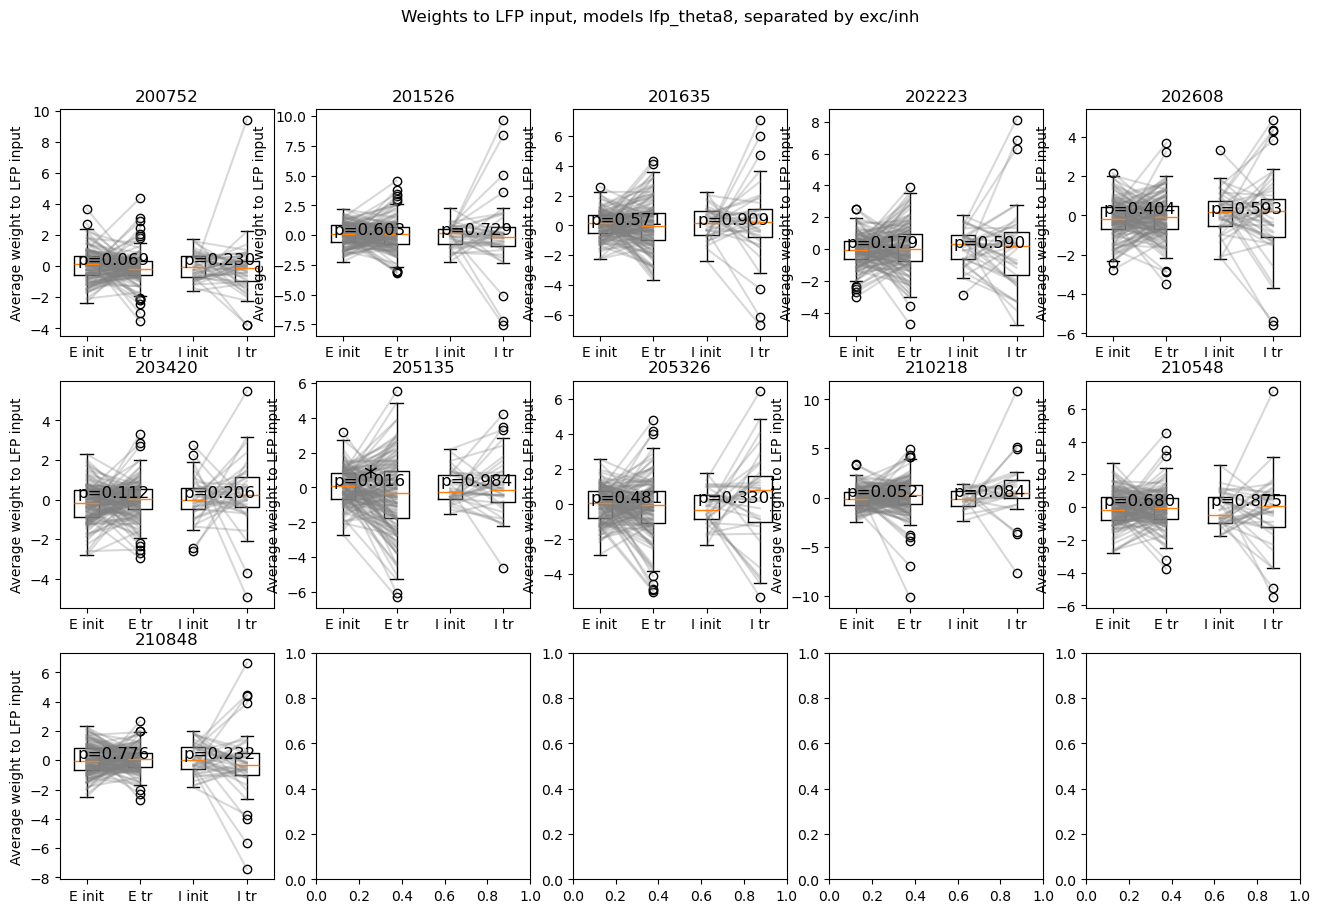

In [12]:
from scipy.stats import wilcoxon

model_lists = [lfp_theta4_model_list, lfp_theta8_model_list] #, lfp_alpha_model_list]
model_dirs = [lfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['lfp_theta4', 'lfp_theta8'] #, 'lfp_alpha']

for (model_list, model_dir, model_list_name) in zip(model_lists, model_dirs, model_list_names):
    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    fig, axs = plt.subplots(3,5, figsize=(16,10))
    axs = axs.flatten()
    for i, model_name in enumerate(model_list):
        model_path = os.path.join(lfp_model_dir, model_name)
        model_data = scipy.io.loadmat(model_path)
        
        w_in_lfp = np.squeeze(model_data['w_in_lfp'])
        w_in_lfp0 = np.squeeze(model_data['w_in_lfp0'])
        exc_ind = np.where(model_data['exc']==1)[0]
        inh_ind = np.where(model_data['exc']==0)[0]
        
        axs[i].boxplot([w_in_lfp0[exc_ind], w_in_lfp[exc_ind],  w_in_lfp0[inh_ind], w_in_lfp[inh_ind]])
        axs[i].set_xticklabels(['E init', 'E tr', 'I init', 'I tr'])
        # plot gray lines
        for j in range(len(exc_ind)):
            axs[i].plot([1, 2], [w_in_lfp0[exc_ind][j], w_in_lfp[exc_ind][j]], color='gray', alpha=0.3)
        for j in range(len(inh_ind)):
            axs[i].plot([3, 4], [w_in_lfp0[inh_ind][j], w_in_lfp[inh_ind][j]], color='gray', alpha=0.3)
        stat, p = wilcoxon(w_in_lfp0[exc_ind], w_in_lfp[exc_ind])
        axs[i].text(1.5, 0.1, f'p={p:.3f}', fontsize=12, ha='center')
        if p<0.05:
            axs[i].text(1.5, 0.1, '*', fontsize=20, ha='center')
        stat, p = wilcoxon(w_in_lfp0[inh_ind], w_in_lfp[inh_ind])
        axs[i].text(3.5, 0.1, f'p={p:.3f}', fontsize=12, ha='center')
        if p<0.05:
            axs[i].text(3.5, 0.1, '*', fontsize=20, ha='center')
        axs[i].set_ylabel('Average weight to LFP input')
        axs[i].set_title(f'{model_name[-10:-4]}')
    plt.suptitle(f'Weights to LFP input, models {model_list_name}, separated by exc/inh')
    plt.show()

Mann-Whitney U test statistic: 44.00, p-value: 0.29


/tmp/ipykernel_846277/1447785612.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([avg_weight_exc, avg_weight_inh], labels=['Exc', 'Inh'])


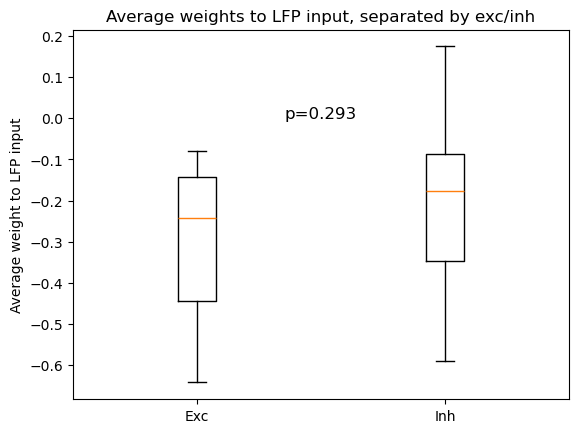

In [13]:
avg_weight_exc = []
avg_weight_inh = []
for i, model_name in enumerate(lfp_theta4_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    
    w_in_lfp = np.squeeze(model_data['w_in_lfp'])
    exc_ind = np.where(model_data['exc']==1)[0]
    inh_ind = np.where(model_data['exc']==0)[0]
    
    avg_weight_exc.append(np.mean(w_in_lfp[exc_ind]))
    avg_weight_inh.append(np.mean(w_in_lfp[inh_ind]))
    
plt.figure()
plt.boxplot([avg_weight_exc, avg_weight_inh], labels=['Exc', 'Inh'])
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(avg_weight_exc, avg_weight_inh)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))
if p<0.05:
    plt.text(1.5, 0, '*', fontsize=20, ha='center')
plt.text(1.5, 0, f'p={p:.3f}', fontsize=12, ha='center')
plt.ylabel('Average weight to LFP input')
plt.title('Average weights to LFP input, separated by exc/inh')
plt.show()

### Plot rate trajectories

Processing model type: lfp_theta4, number of models: 11
PCA explained variance: [0.2930846  0.22651715 0.16054636], total: 0.6801481113277885
PCA explained variance: [0.34878756 0.18787396 0.13235139], total: 0.6690129144047939
PCA explained variance: [0.399689   0.29024439 0.06724331], total: 0.7571766991251156
PCA explained variance: [0.35792527 0.27384848 0.12750491], total: 0.7592786607160471
PCA explained variance: [0.36170431 0.27764571 0.09316181], total: 0.7325118350738018
PCA explained variance: [0.41647199 0.21459984 0.09271606], total: 0.7237878927128828
PCA explained variance: [0.37257608 0.28814383 0.09867042], total: 0.7593903306453857
PCA explained variance: [0.46521133 0.24761372 0.06624061], total: 0.7790656587278446
PCA explained variance: [0.44484659 0.26577295 0.06479649], total: 0.775416026979435
PCA explained variance: [0.40384747 0.28574379 0.05872098], total: 0.7483122313237734
PCA explained variance: [0.39757453 0.33865329 0.05822173], total: 0.794449552406541


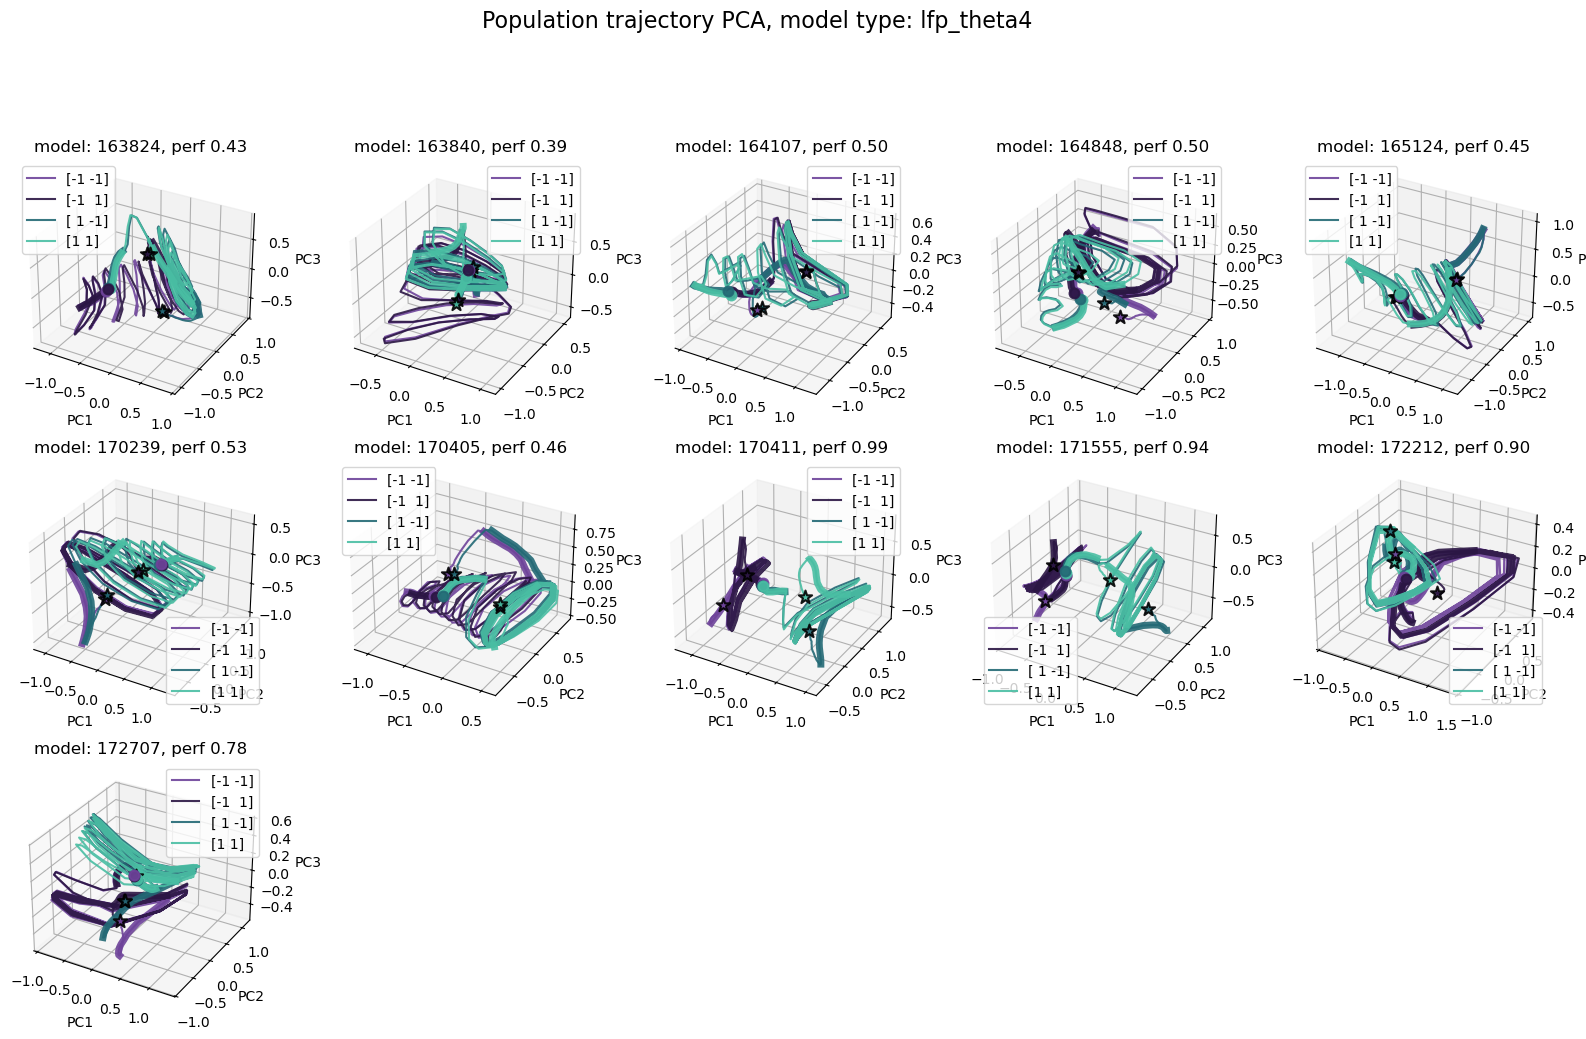

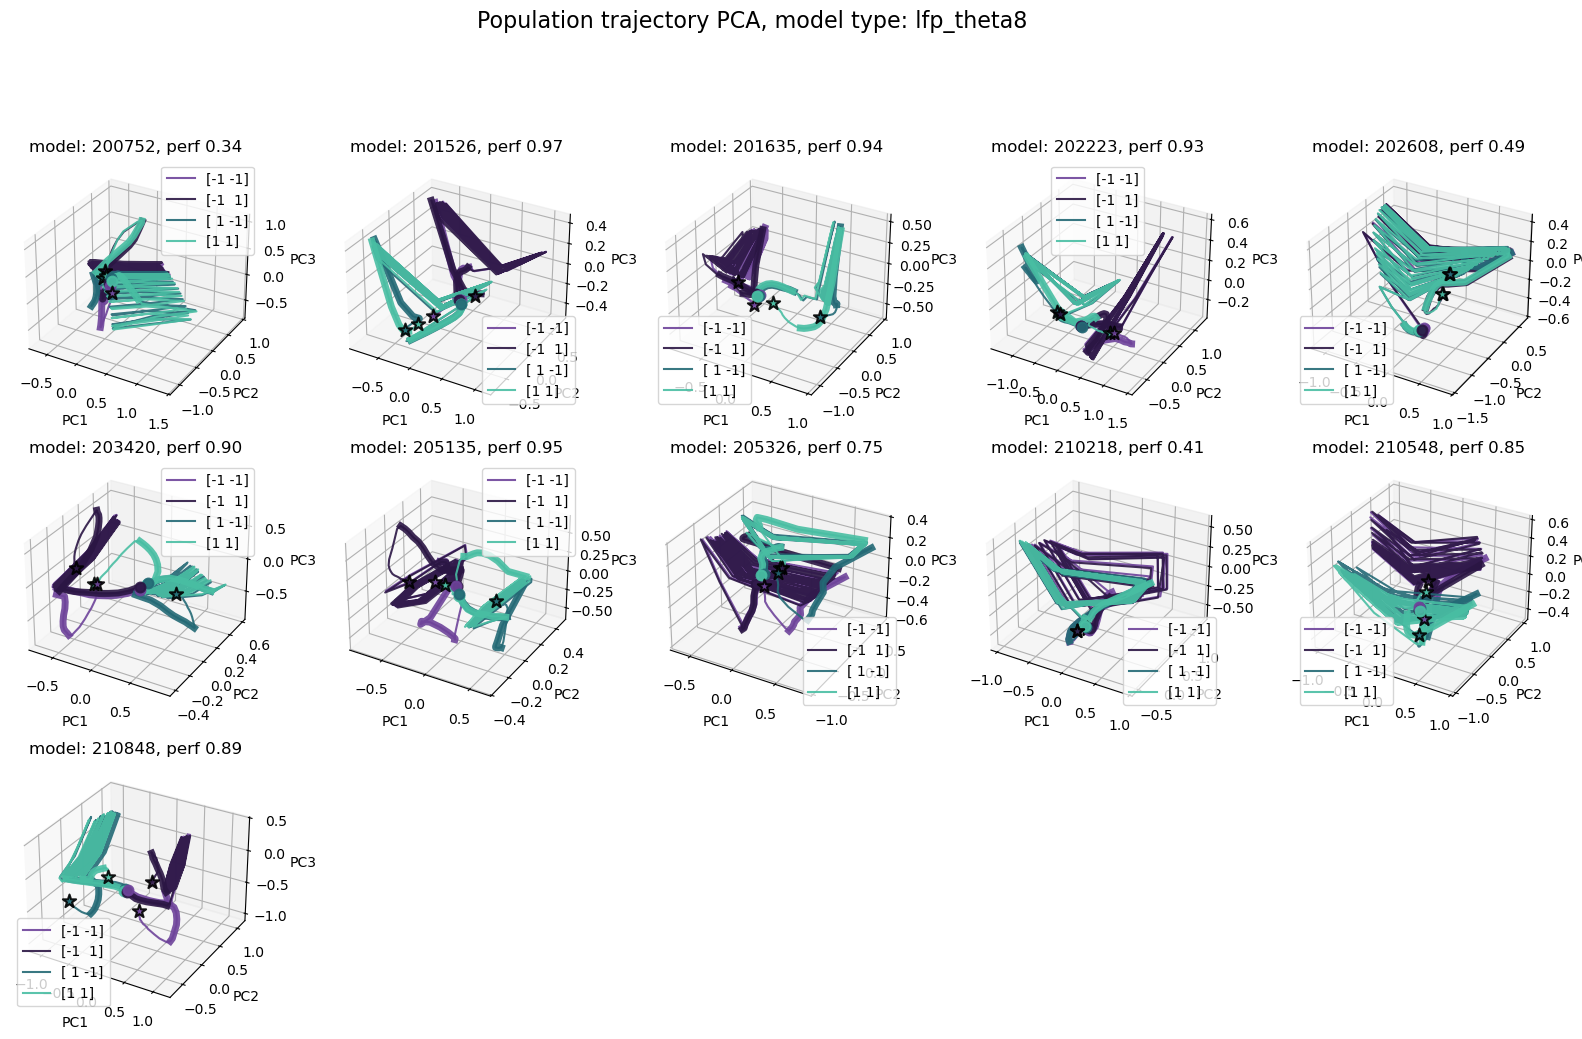

In [14]:
model_lists = [lfp_theta4_model_list, lfp_theta8_model_list] #, lfp_alpha_model_list]
model_dirs = [lfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['lfp_theta4', 'lfp_theta8'] #, 'lfp_alpha']
condn = 'delay400'

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15))

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, f'neural_dict_{condn}.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, f'bhv_dict_{condn}.pkl'), 'rb'))
        
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1, projection='3d')
        ax, _ = pu.plot_trajectory_pca(rates_data=neural_dict['r'], trial_labels=np.array(bhv_dict['trial_type']), 
                       settings=settings, cut_off=50, plot=1, ds=5, smooth=2, ax=ax,
                       title=f'model: {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    
    fig.suptitle(f'Population trajectory PCA, model type: {model_list_name}', fontsize=16)


### plot EPSP

In [16]:
# spect calculation function in numpy -- z-score the epsp signal

def compute_lfp_power_zscore_lfp_np(epsp, settings, baseline_start=10):
    """
    Compute band-limited z-scored LFP power using Morlet wavelets (NumPy version).

    Parameters
    ----------
    epsp : list or np.ndarray
        Length-T list or array of scalar values (e.g., EPSP signal).
    settings : dict
        Dictionary containing:
            - 'T': int, length of the signal
            - 'fs': float, sampling frequency in Hz
            - 'lfp_power_target': list or tuple of [low_freq, high_freq]
            - 'stim_on': int, time index of stimulus onset

    Returns
    -------
    lfp_power_z : np.ndarray
        Z-scored LFP power in the target frequency band. Shape [T]
    """
    # --- settings ---
    T = settings['T']
    fs = settings['fs']
    dt = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_target = settings['lfp_power_target']
    if len(band_target) == 1:
        band_lo = band_target[0] - 0.5
        band_hi = band_target[0] + 0.5
    elif len(band_target) == 2:
        band_lo, band_hi = band_target
    else:
        raise ValueError("lfp_power_target must be a list or tuple of length 1 or 2.")
    stim_on = settings['stim_on']
    
     # --- baseline z-scoring ---
    # start = 10
    stop = int(stim_on)
    base_slice = epsp[baseline_start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    epsp = (epsp - base_mean) / base_std  # [T]

    # --- epsp input processing ---
    epsp_vec = np.squeeze(np.stack(epsp, axis=0))  # [T]
    epsp_sig = np.reshape(epsp_vec, [1, T, 1])      # [1, T, 1]

    # --- frequencies & scales ---
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))
    fc = 0.8125  # Morlet central frequency
    scales = fc / (freqs * dt)

    # --- build Morlet kernels ---
    K = 6.0
    f_low = fmin
    sigma_t_low = K / (2.0 * np.pi * f_low)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)

    t_idx = np.arange(kernel_len, dtype=np.float32) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]

    env = np.exp(-0.5 * (np.expand_dims(t_sec, 1) / np.expand_dims(sigma_t, 0))**2)
    phase = two_pi * np.expand_dims(t_sec, 1) * np.expand_dims(freqs, 0)
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # L2 normalize
    eps_norm = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps_norm)
    cos_part /= norm
    sin_part /= norm

    # Filters: [L, 1, F]
    cos_filt = np.expand_dims(cos_part, axis=1)
    sin_filt = np.expand_dims(sin_part, axis=1)

    # --- convolution with SAME padding ---
    def conv1d_same(x, filt):
        pad_len = filt.shape[0] // 2
        x_padded = np.pad(x, ((0, 0), (pad_len, pad_len), (0, 0)), mode='constant')
        output = np.zeros((x.shape[0], x.shape[1], filt.shape[2]))
        for f in range(filt.shape[2]):
            kernel = filt[:, 0, f][::-1]  # reverse for conv
            for b in range(x.shape[0]):
                output[b,:,f] = np.convolve(x_padded[b,:,0], kernel, mode='valid')
        return output

    real_coeff = conv1d_same(epsp_sig, cos_filt)  # [1, T, F]
    imag_coeff = conv1d_same(epsp_sig, sin_filt)  # [1, T, F]
    power = real_coeff**2 + imag_coeff**2        # [1, T, F]
    power = np.squeeze(power, axis=0)            # [T, F]

    # --- band selection ---
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = np.dot(power, band_mask_f / denom)  # [T]
    
    # # --- z-score band power ---
    # base_slice = band_power[baseline_start:stop]
    # base_mean = np.mean(base_slice)
    # base_std = np.std(base_slice) + 1e-8
    # lfp_power_z = (band_power - base_mean) / base_std  # [


    return power, freqs, band_power


Processing model type: lfp_theta4, number of models: 11
Processing model type: lfp_theta8, number of models: 11


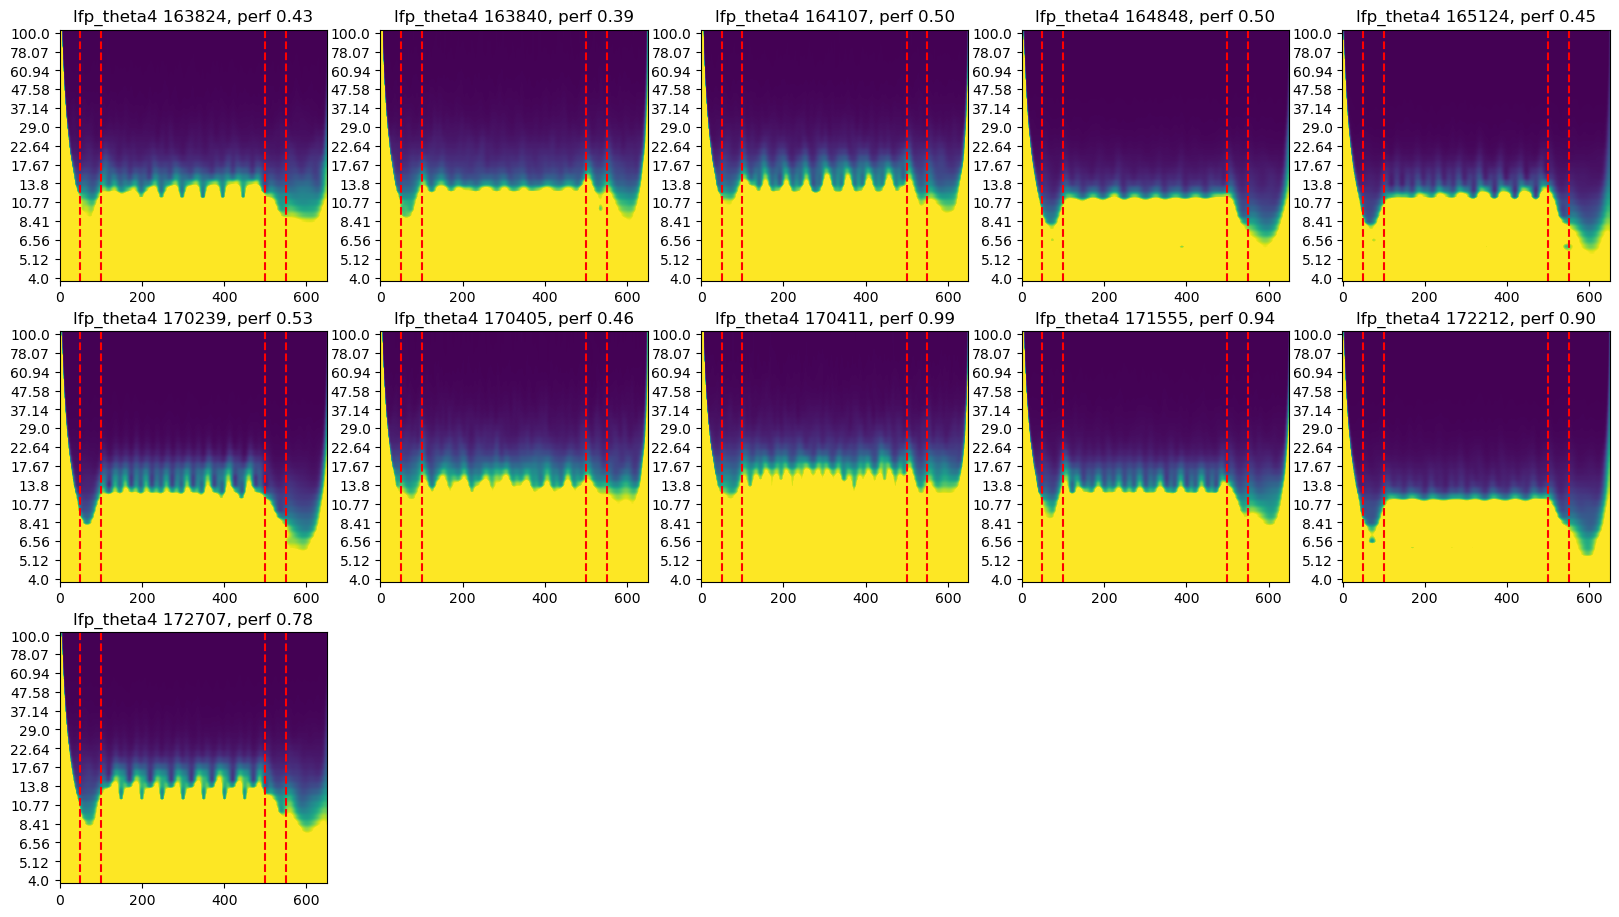

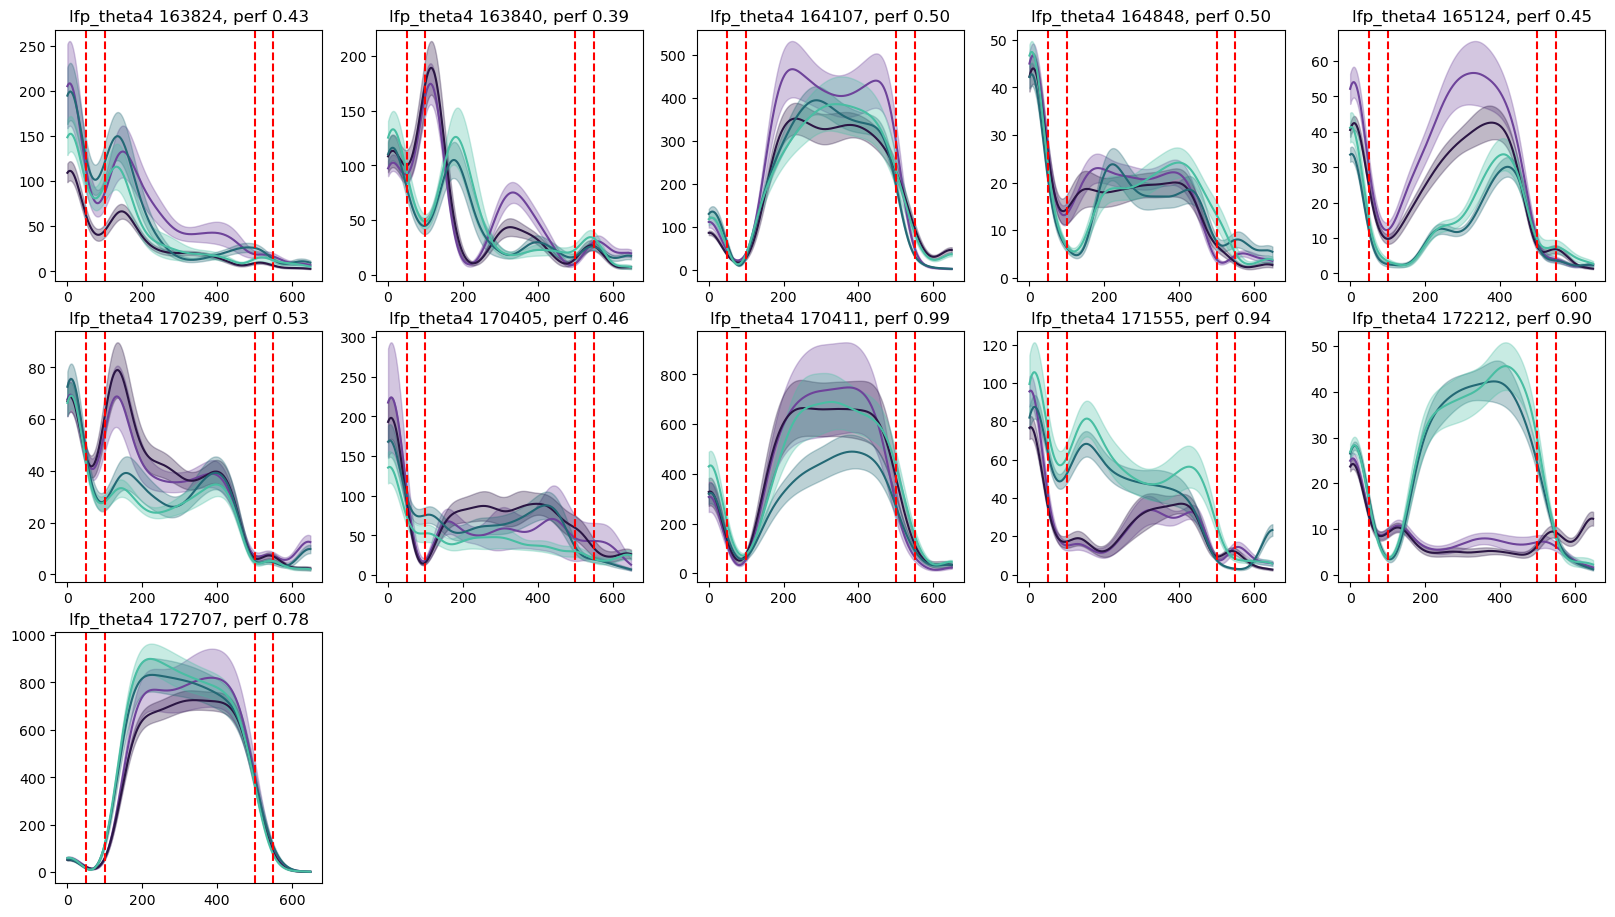

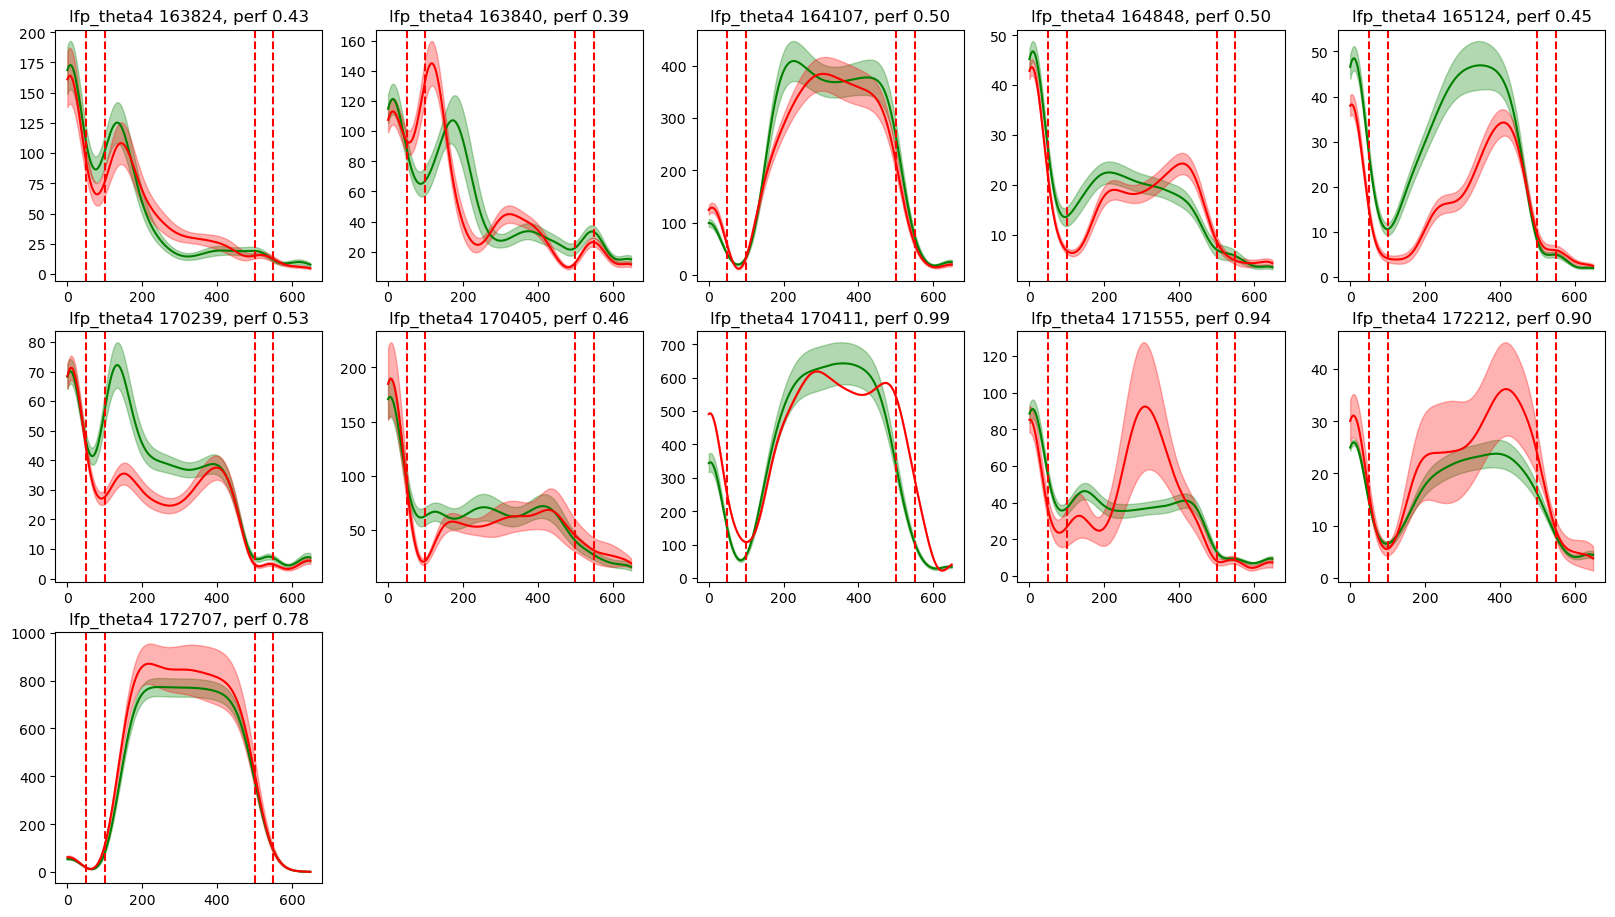

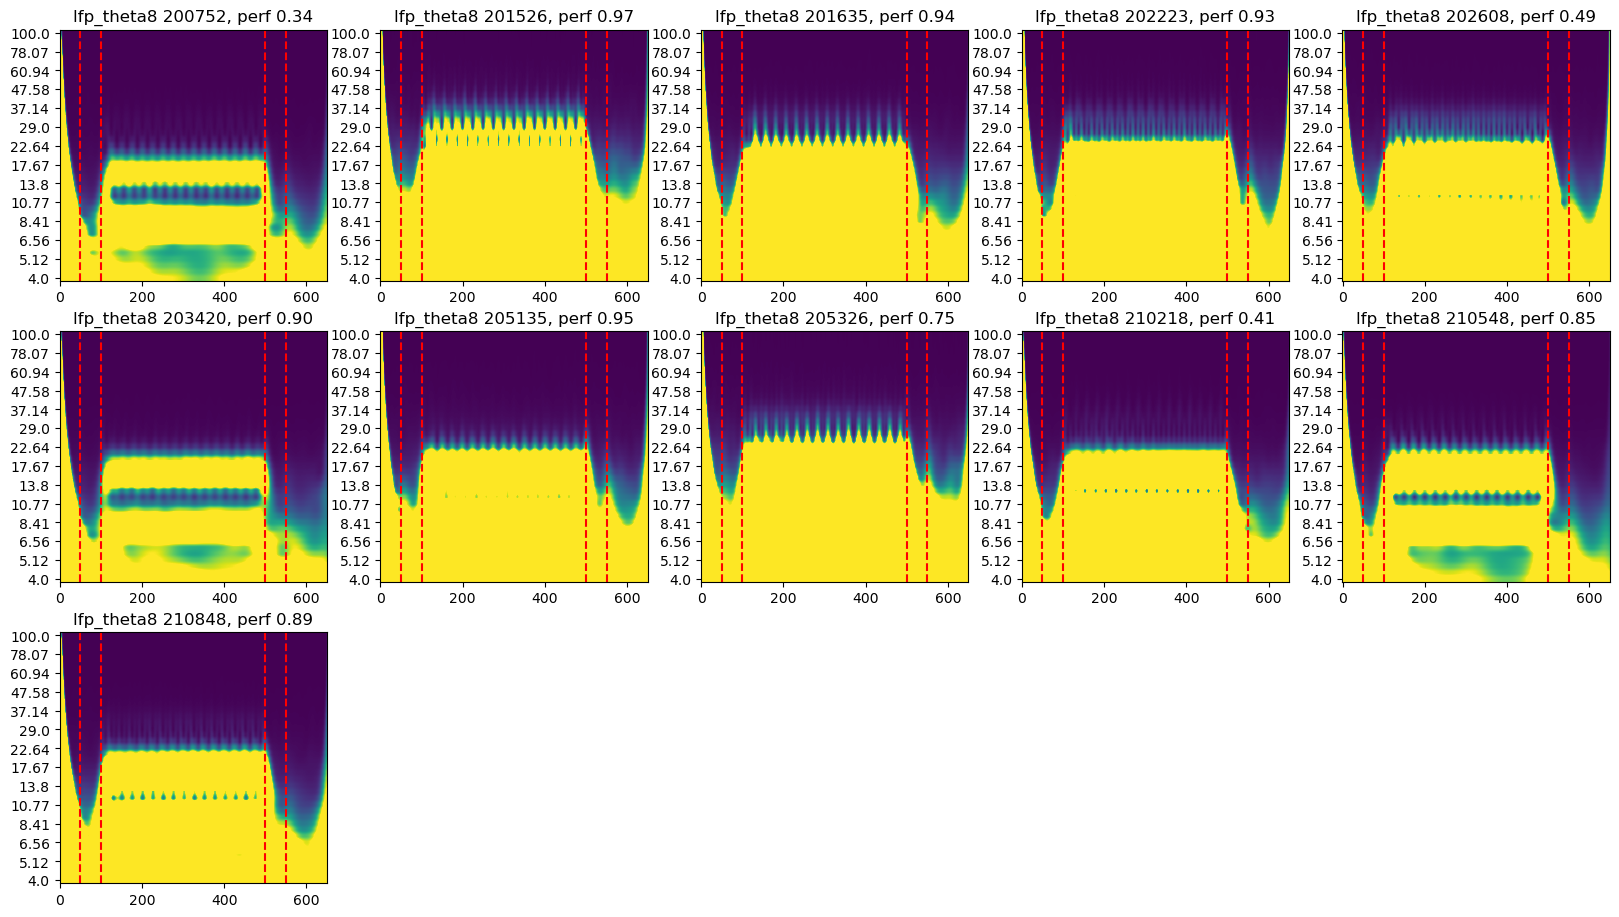

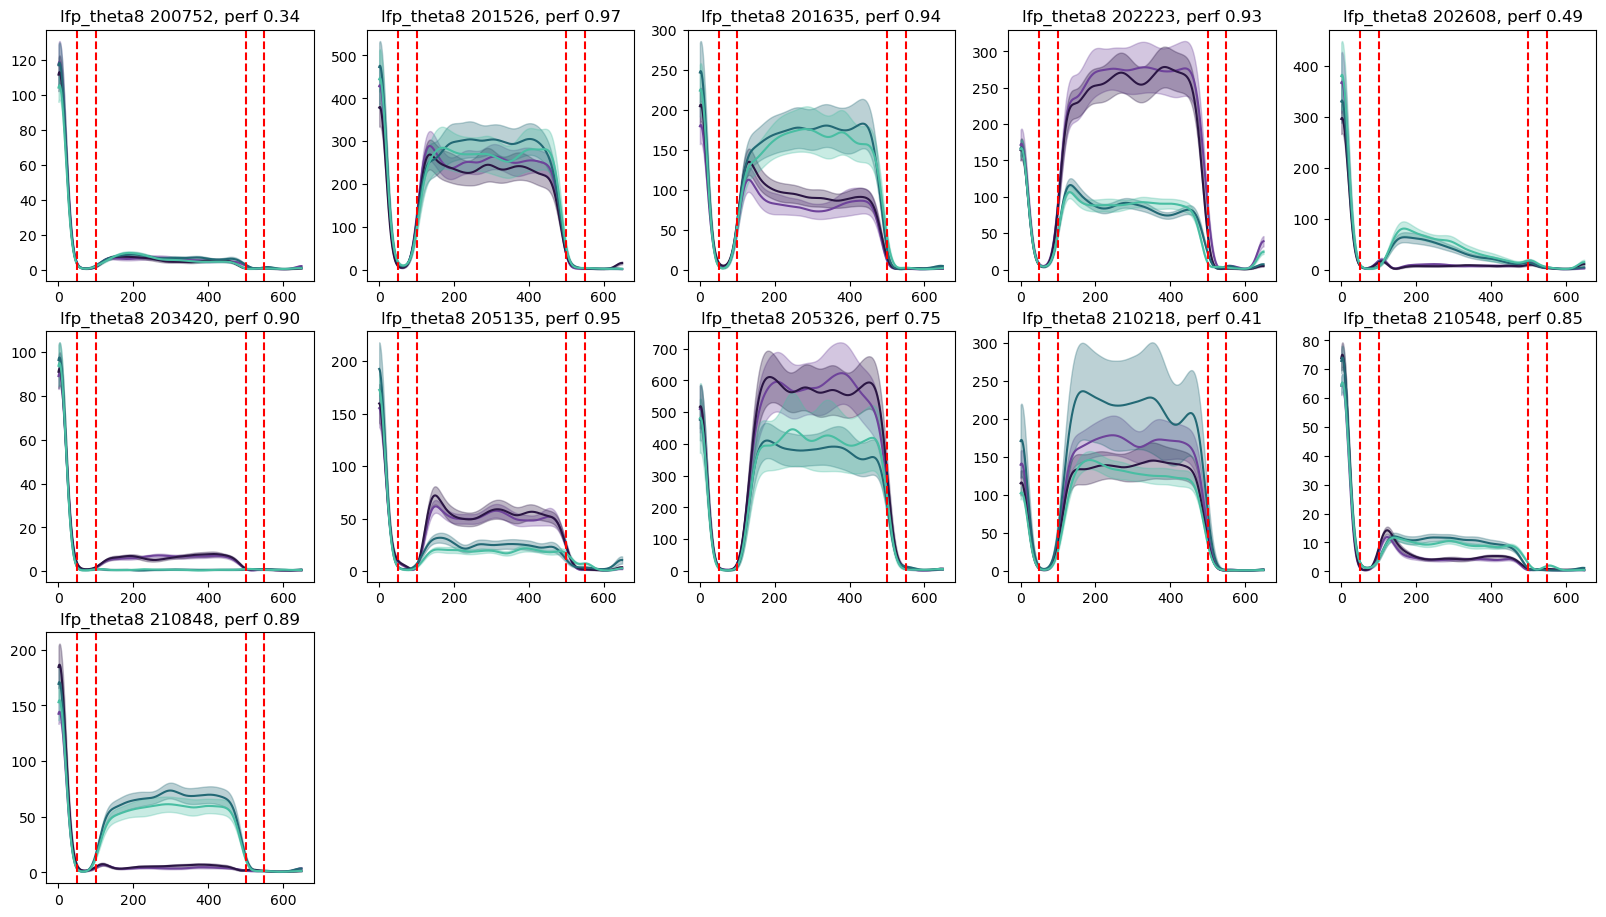

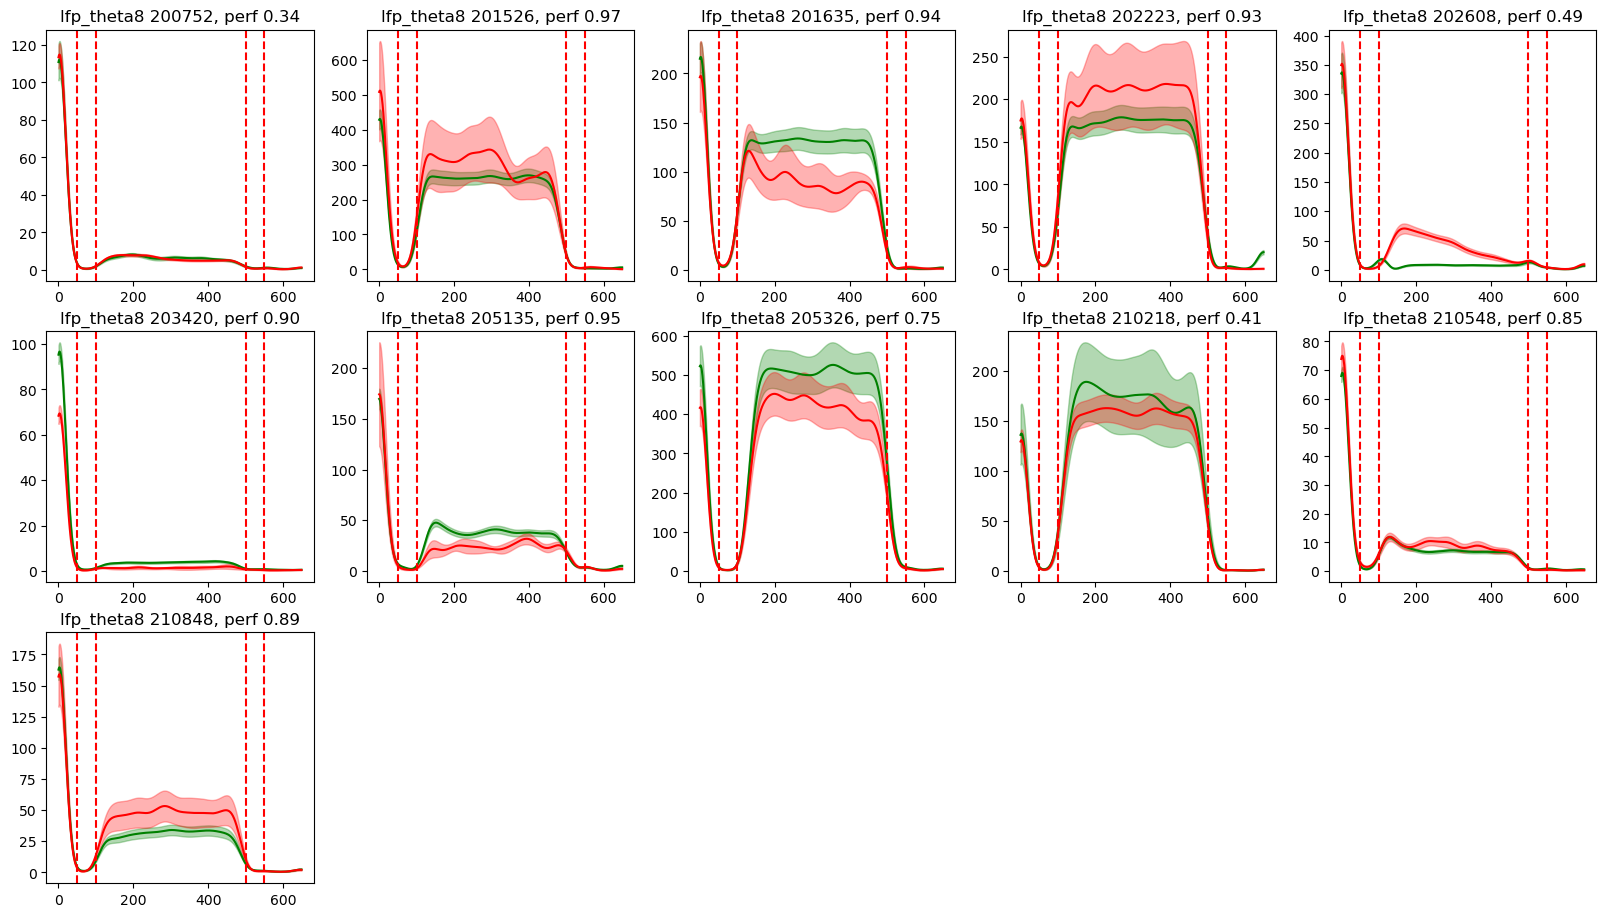

In [17]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect -- z-score epsp signal

model_lists = [lfp_theta4_model_list, lfp_theta8_model_list] #, lfp_alpha_model_list]
model_dirs = [lfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['lfp_theta4', 'lfp_theta8'] #, 'lfp_alpha']
model_powers = [4, 8]
condn = 'delay400'

for model_list, model_dir, model_list_name, model_power in zip(model_lists, model_dirs, model_list_names, model_powers):
    settings['lfp_power_target'] = [model_power]

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig1 = plt.figure(figsize=(20, 15)) # spectrogram
    fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
    fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, f'neural_dict_{condn}.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, f'bhv_dict_{condn}.pkl'), 'rb'))
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = neural_dict['epsp'].shape[0]

        trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
        avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
        for i in range(n_trials):
            trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_zscore_lfp_np(neural_dict['epsp'][i, :], settings, baseline_start=10)
            avg_power += trial_power / n_trials
            
        # first plot spectrogram
        ax1 = fig1.add_subplot(4, 5, model_list.index(model_name)+1)
        ax1.imshow(avg_power.T, aspect='auto', origin='lower',
               vmin=0, vmax=1.2)
        ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
        # ax1.colorbar(label='Power')
        ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax1.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
        
        # then plot band power, split by trial type
        ax2 = fig2.add_subplot(4, 5, model_list.index(model_name)+1)
        stims, colors = ld.get_trialtype_colors()
        trial_types, trial_idxs = np.unique(np.array(bhv_dict['trial_type']), axis=0, return_inverse=True)
        for i, trial_type in enumerate(trial_types):
            trials_idx = (trial_idxs == i)
            powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
            powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
            ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
            ax2.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
        ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax2.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
        
        # finally plot band power, split by correct/incorrect
        ax3 = fig3.add_subplot(4, 5, model_list.index(model_name)+1)
        correct_trials = (np.array(bhv_dict['perf']) == 1)
        incorrect_trials = (np.array(bhv_dict['perf']) == 0)
        powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
        ax3.plot(powerband_mean, color='g', label='correct')
        ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
        powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
        ax3.plot(powerband_mean, color='r', label='incorrect')
        ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
        ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax3.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



Processing model type: lfp_theta4, number of models: 13
Processing model type: lfp_theta8, number of models: 8


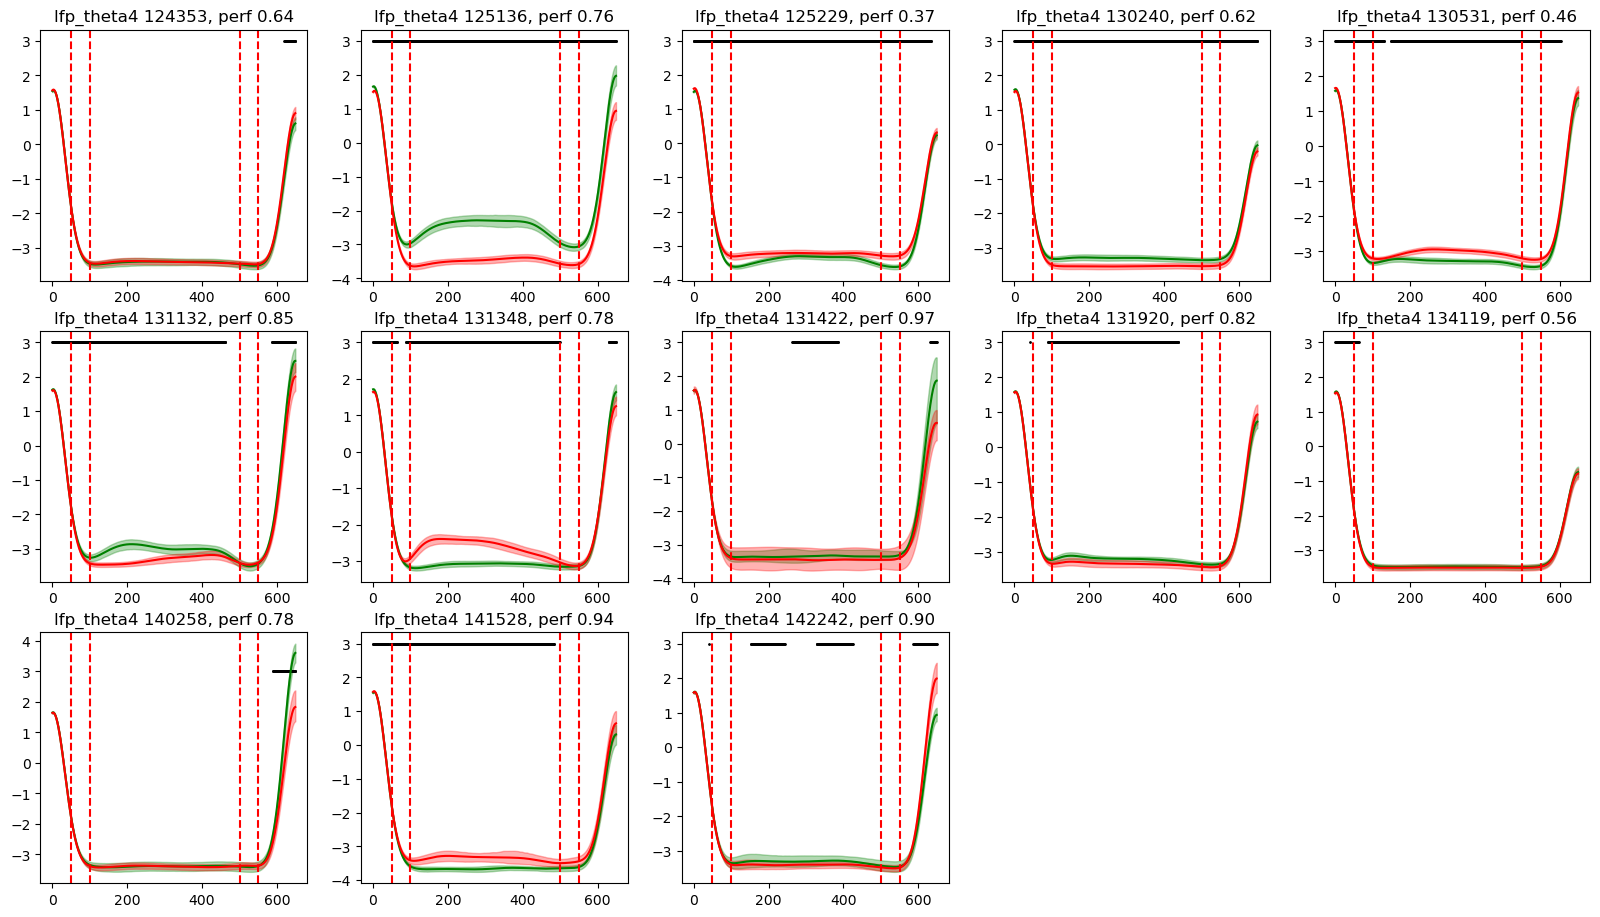

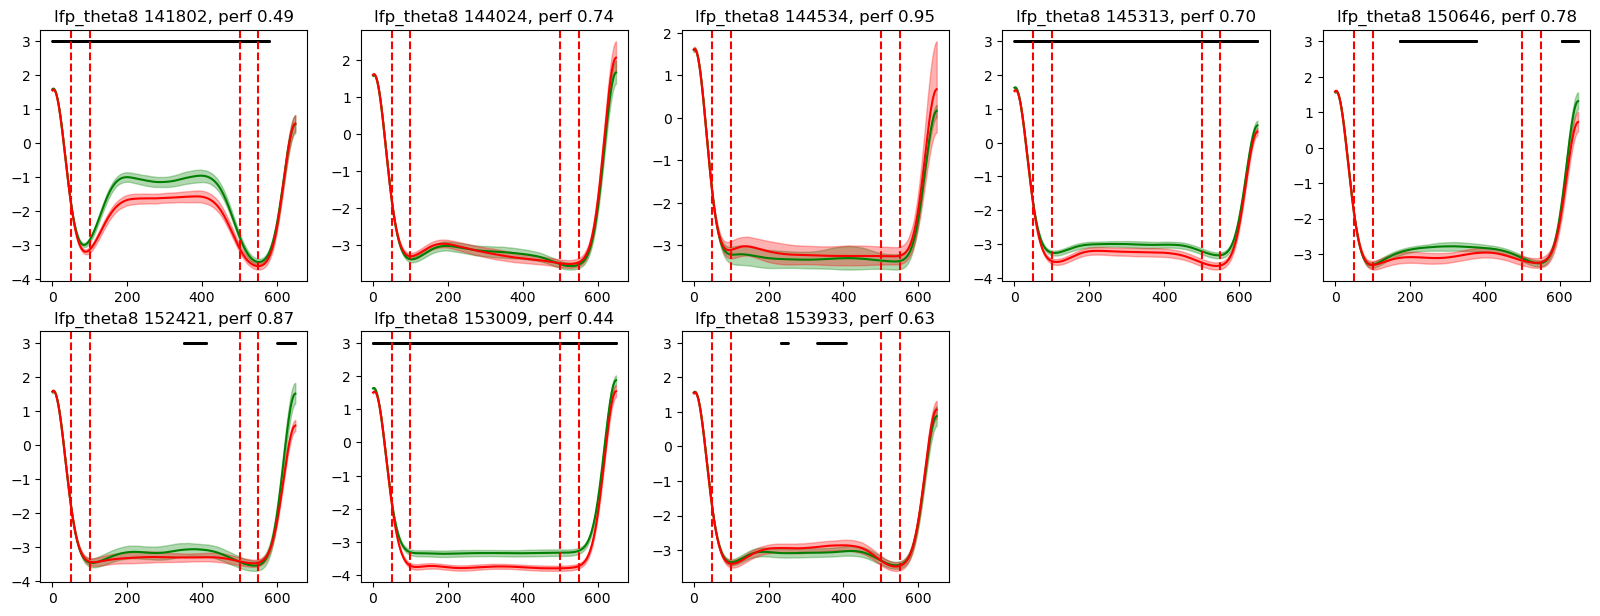

In [20]:
# make plot: bandpower by correct/incorrect w bootstrapping

from bootstrap_method import fnc_time_bootstrap_optimized_retX

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)

model_lists = [lfp_theta4_model_list, lfp_theta8_model_list] #, lfp_alpha_model_list]
model_dirs = [lfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['lfp_theta4', 'lfp_theta8'] #, 'lfp_alpha']
condn = 'delay400'

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, f'neural_dict_{condn}.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, f'bhv_dict_{condn}.pkl'), 'rb'))
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = neural_dict['epsp'].shape[0]

        trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
        avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
        for i in range(n_trials):
            trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
            avg_power += trial_power / n_trials
            
        # finally plot band power, split by correct/incorrect
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1)
        correct_trials = (np.array(bhv_dict['perf']) == 1)
        incorrect_trials = (np.array(bhv_dict['perf']) == 0)
        
        t1_avg, t1_CI, t2_avg, t2_CI, diff_avg, diff_CI, p_diff = fnc_time_bootstrap_optimized_retX(trial_powerband[correct_trials, :], 
                                                                                               trial_powerband[incorrect_trials, :], 
                                                                                               nboot, CI_int, n_jobs=-1, random_seed=None)
        
        ax.plot(t1_avg.mean(axis=1), color='g', label='correct')
        ax.fill_between(np.arange(settings['T']), t1_CI[:,0], t1_CI[:,1], color='g', alpha=0.3)
        powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
        ax.plot(t2_avg.mean(axis=1), color='r', label='incorrect')
        ax.fill_between(np.arange(settings['T']), t2_CI[:,0], t2_CI[:,1], color='r', alpha=0.3)
        # plot bar for significant difference
        sig_idx = np.where(p_diff < 0.05)[0]
        ax.scatter(sig_idx, np.ones_like(sig_idx)*3, color='k', s=1)
        ax.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')

